In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hgultekin/bbcnewsarchive")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bbcnewsarchive' dataset.
Path to dataset files: /kaggle/input/bbcnewsarchive


In [ ]:
import pandas as pd
import os

file_path = os.path.join(
    path,
    "bbc-news-data.csv"
)

df = pd.read_csv(
    file_path,
    sep="\t"
)

print(df.columns)
print(df.head())

Index(['category', 'filename', 'title', 'content'], dtype='object')
   category filename                              title  \
0  business  001.txt  Ad sales boost Time Warner profit   
1  business  002.txt   Dollar gains on Greenspan speech   
2  business  003.txt  Yukos unit buyer faces loan claim   
3  business  004.txt  High fuel prices hit BA's profits   
4  business  005.txt  Pernod takeover talk lifts Domecq   

                                             content  
0   Quarterly profits at US media giant TimeWarne...  
1   The dollar has hit its highest level against ...  
2   The owners of embattled Russian oil giant Yuk...  
3   British Airways has blamed high fuel prices f...  
4   Shares in UK drinks and food firm Allied Dome...  


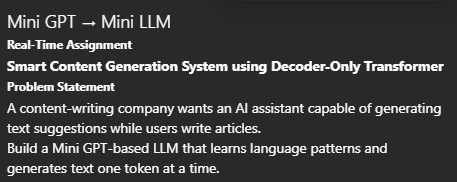

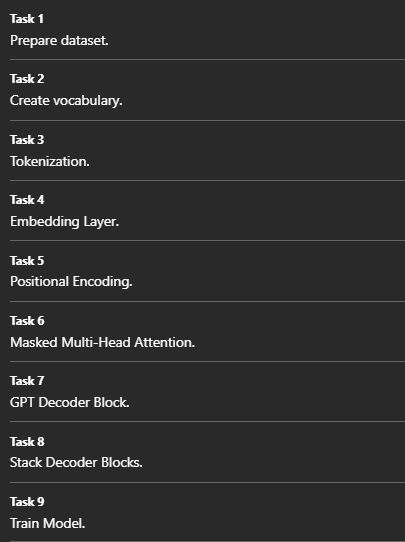

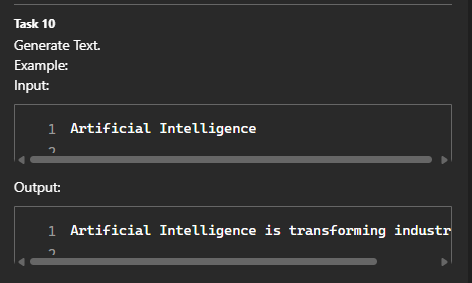

## ***TASK-1 DATASET PREPROCESSING***

In [ ]:
import pandas as pd
import re

# Select Title + Content
texts = (
    df["title"].fillna("") +
    " " +
    df["content"].fillna("")
).tolist()

# Use subset for training
texts = texts[:1500]

# Text Cleaning Function
def clean_text(text):

    text = text.lower()

    text = re.sub(
        r'[^a-zA-Z\s]',
        '',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text

# Apply Cleaning
texts = [
    clean_text(text)
    for text in texts
]

print("Number of Articles:", len(texts))

print("\nSample Records:\n")

for i in range(3):
    print(texts[i][:300])
    print("-" * 80)

Number of Articles: 1500

Sample Records:

ad sales boost time warner profit quarterly profits at us media giant timewarner jumped to bn m for the three months to december from m yearearlier the firm which is now one of the biggest investors in google benefited from sales of highspeed internet connections and higher advert sales timewarner s
--------------------------------------------------------------------------------
dollar gains on greenspan speech the dollar has hit its highest level against the euro in almost three months after the federal reserve head said the us trade deficit is set to stabilise and alan greenspan highlighted the us governments willingness to curb spending and rising household savings as fa
--------------------------------------------------------------------------------
yukos unit buyer faces loan claim the owners of embattled russian oil giant yukos are to ask the buyer of its former production unit to pay back a m m loan stateowned rosneft bought the yugansk

## ***TASK-2 VOCABULARY CREATION***

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()

tokenizer.fit_on_texts(texts)

word_index = tokenizer.word_index

index_word = {
    v:k
    for k,v in word_index.items()
}

vocab_size = len(word_index) + 1

print("Vocabulary Size:", vocab_size)

print("\nSample Word -> Index Mapping\n")

for word, idx in list(word_index.items())[:10]:

    print(word, "->", idx)

print("\nSample Index -> Word Mapping\n")

for idx, word in list(index_word.items())[:10]:

    print(idx, "->", word)

Vocabulary Size: 24948

Sample Word -> Index Mapping

the -> 1
to -> 2
of -> 3
in -> 4
and -> 5
a -> 6
for -> 7
is -> 8
said -> 9
on -> 10

Sample Index -> Word Mapping

1 -> the
2 -> to
3 -> of
4 -> in
5 -> and
6 -> a
7 -> for
8 -> is
9 -> said
10 -> on


## ***TASK-3 TOKENIZATION***

In [ ]:
sequences = []

for text in texts:

    tokens = tokenizer.texts_to_sequences(
        [text]
    )[0]

    # limit length
    tokens = tokens[:50]

    for i in range(1, len(tokens)):

        sequences.append(
            (
                tokens[:i],
                tokens[i]
            )
        )

print("Total Sequences:", len(sequences))

print("\nSample Tokenized Sequence:\n")

print(sequences[0])

Total Sequences: 73500

Sample Tokenized Sequence:

([5385], 129)


## ***Task 4: Embedding Layer***

In [ ]:
import tensorflow as tf

embedding_dim = 32

embedding_layer = tf.keras.layers.Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim
)

sample_input = tf.constant([[1, 2, 3]])

embedded = embedding_layer(
    sample_input
)

print("Embedding Shape:")
print(embedded.shape)

print("\nSample Embeddings:")
print(embedded)

Embedding Shape:
(1, 3, 32)

Sample Embeddings:
tf.Tensor(
[[[-0.02691284  0.01416374  0.0069636  -0.04875813 -0.01221733
   -0.00553062 -0.01485531 -0.00478842  0.00882827 -0.00729799
    0.01809677  0.00511222  0.00480314 -0.04470075  0.03870938
   -0.03055327 -0.04833529  0.0449556  -0.03943213  0.02141005
    0.00320556  0.01701962 -0.01756565  0.04842521 -0.00701332
    0.03572318 -0.03112449  0.03174479  0.01431947  0.03872612
    0.03259051 -0.01679983]
  [ 0.04941144  0.04523538 -0.00047741 -0.00855014 -0.03481702
    0.01295848 -0.04121679  0.03914667 -0.00902405 -0.02795379
   -0.01215965 -0.00474149 -0.02549042  0.0290187  -0.00845939
   -0.04936118  0.01703829 -0.01144882 -0.02001846 -0.01555206
    0.0104689  -0.04921931 -0.00902259  0.03364548 -0.02552238
   -0.00317289  0.0240566   0.03223275 -0.00551093  0.02580972
   -0.00938798 -0.00620583]
  [-0.02000516  0.02266162 -0.04275403  0.03939617  0.02637515
   -0.03758663 -0.04300488  0.00368488 -0.03141658 -0.00419818
   

## ***Task 5: Positional Encoding***

In [ ]:
import numpy as np

def positional_encoding(
    max_len,
    d_model
):

    pos = np.arange(max_len)[:, np.newaxis]

    i = np.arange(d_model)[np.newaxis, :]

    angle_rates = 1 / np.power(
        10000,
        (2 * (i // 2)) / np.float32(d_model)
    )

    angles = pos * angle_rates

    pe = np.zeros(
        (max_len, d_model)
    )

    pe[:, 0::2] = np.sin(
        angles[:, 0::2]
    )

    pe[:, 1::2] = np.cos(
        angles[:, 1::2]
    )

    return pe

pe = positional_encoding(
    10,
    32
)

print("Positional Encoding Shape:")
print(pe.shape)

print("\nFirst Position:")
print(pe[0])

print("\nSecond Position:")
print(pe[1])

Positional Encoding Shape:
(10, 32)

First Position:
[0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.
 0. 1. 0. 1. 0. 1. 0. 1.]

Second Position:
[8.41470985e-01 5.40302306e-01 5.33168440e-01 8.46009110e-01
 3.10983593e-01 9.50415280e-01 1.76892186e-01 9.84230234e-01
 9.98334166e-02 9.95004165e-01 5.62044992e-02 9.98419278e-01
 3.16175064e-02 9.99500042e-01 1.77818569e-02 9.99841890e-01
 9.99983333e-03 9.99950000e-01 5.62338361e-03 9.99984189e-01
 3.16227239e-03 9.99995000e-01 1.77827847e-03 9.99998419e-01
 9.99999833e-04 9.99999500e-01 5.62341296e-04 9.99999842e-01
 3.16227761e-04 9.99999950e-01 1.77827940e-04 9.99999984e-01]


## ***Task 6: Masked Multi-Head Attention***

In [ ]:
import tensorflow as tf

seq_len = 5

mask = 1 - tf.linalg.band_part(
    tf.ones(
        (seq_len, seq_len)
    ),
    -1,
    0
)

print("Causal Mask:\n")
print(mask.numpy())


mha = tf.keras.layers.MultiHeadAttention(
    num_heads=4,
    key_dim=32
)

x = tf.random.normal(
    (2, 5, 32)
)

attn_output = mha(
    x,
    x,
    attention_mask=mask
)

print("Attention Output Shape:")
print(attn_output.shape)

Causal Mask:

[[0. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]]
Attention Output Shape:
(2, 5, 32)


## ***Task 7: GPT Decoder Block***

In [ ]:
import tensorflow as tf

class DecoderBlock(
    tf.keras.layers.Layer
):

    def __init__(
        self,
        num_heads,
        d_model,
        dff,
        rate=0.1
    ):
        super().__init__()

        self.mha = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model
        )

        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(
                dff,
                activation="relu"
            ),
            tf.keras.layers.Dense(
                d_model
            )
        ])

        self.dropout1 = tf.keras.layers.Dropout(rate)

        self.dropout2 = tf.keras.layers.Dropout(rate)

        self.norm1 = tf.keras.layers.LayerNormalization()

        self.norm2 = tf.keras.layers.LayerNormalization()

    def call(
        self,
        x,
        training=False
    ):

        attn_output = self.mha(
            x,
            x
        )

        attn_output = self.dropout1(
            attn_output,
            training=training
        )

        x = self.norm1(
            x + attn_output
        )

        ffn_output = self.ffn(x)

        ffn_output = self.dropout2(
            ffn_output,
            training=training
        )

        x = self.norm2(
            x + ffn_output
        )

        return x

## ***Task 8: Build Mini GPT Model***

In [ ]:
import tensorflow as tf

inputs = tf.keras.Input(
    shape=(None,)
)

# Token Embedding
x = tf.keras.layers.Embedding(
    vocab_size,
    32
)(inputs)

# Decoder Blocks
decoder1 = DecoderBlock(
    num_heads=4,
    d_model=32,
    dff=64
)

decoder2 = DecoderBlock(
    num_heads=4,
    d_model=32,
    dff=64
)

x = decoder1(x)

x = decoder2(x)

# Last Token Representation
x = tf.keras.layers.Lambda(
    lambda t: t[:, -1, :]
)(x)

# Final Linear Layer
outputs = tf.keras.layers.Dense(
    vocab_size,
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, None, 32)       │       798,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_block_2 (DecoderBlock)  │ (None, None, 32)       │        21,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_block_3 (DecoderBlock)  │ (None, None, 32)       │        21,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 24948)          │       823,284 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,663,860 (6.35 MB)

 Trainable params: 1,663,860 (6.35 MB)

 Non-trainable params: 0 (0.00 B)

## ***Task 9: Train Model***

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = []
y = []

for seq in sequences:

    X.append(seq[0])

    y.append(seq[1])

max_len = max(
    len(seq)
    for seq in X
)

X = pad_sequences(
    X,
    maxlen=max_len,
    padding="pre"
)

y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (73500, 49)
y Shape: (73500,)


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    X,
    y,
    epochs=15,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/15
2068/2068 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - accuracy: 0.0698 - loss: 7.3999 - val_accuracy: 0.0758 - val_loss: 7.8215
Epoch 2/15
2068/2068 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.1163 - loss: 6.3648 - val_accuracy: 0.0883 - val_loss: 7.9423
Epoch 3/15
2068/2068 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.1607 - loss: 5.6935 - val_accuracy: 0.0955 - val_loss: 8.1793
Epoch 4/15
2068/2068 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.1969 - loss: 5.1250 - val_accuracy: 0.1003 - val_loss: 8.5380
Epoch 5/15
2068/2068 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.2272 - loss: 4.6533 - val_accuracy: 0.0980 - val_loss: 8.8233
Epoch 6/15
2068/2068 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.2510 - loss: 4.2906 - val_accuracy: 0.1031 - val_loss: 9.2205
Epoch 7/15
2068/2068 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.2676 - loss: 4.0038 - val_accuracy: 0.1035 - val_loss: 9.5153
Epoch 8/15
2068/2068 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.2868 - loss: 

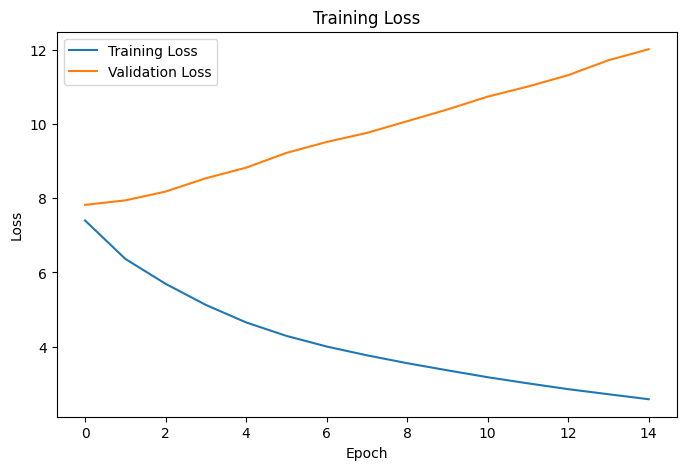

In [ ]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8,5)
)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.show()

In [ ]:
index_word = {
    v:k
    for k,v in word_index.items()
}

In [ ]:
import re
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_next_word(text):

    text = re.sub(
        r'[^a-zA-Z\s]',
        '',
        text.lower()
    )

    seq = tokenizer.texts_to_sequences(
        [text]
    )[0]

    seq = pad_sequences(
        [seq],
        maxlen=max_len,
        padding="pre"
    )

    pred = model.predict(
        seq,
        verbose=0
    )

    top_k = 5

    top_indices = np.argsort(
        pred[0]
    )[-top_k:]

    next_word_id = np.random.choice(
        top_indices
    )

    return index_word.get(
        next_word_id,
        ""
    )

In [ ]:
def generate_text(
    seed_text,
    num_words
):

    for _ in range(num_words):

        next_word = predict_next_word(
            seed_text
        )

        if next_word == "":
            break

        seed_text += " " + next_word

    return seed_text

In [ ]:
print("Example 1")
print(
    generate_text(
        "artificial intelligence",
        20
    )
)

print("\nExample 2")
print(
    generate_text(
        "machine learning",
        20
    )
)

print("\nExample 3")
print(
    generate_text(
        "technology companies",
        20
    )
)

print("\nExample 4")
print(
    generate_text(
        "financial markets",
        20
    )
)

print("\nExample 5")
print(
    generate_text(
        "mobile phones",
        20
    )
)

Example 1
artificial intelligence left interest rate shares at in the worlds largest restaurant and actor ossie act in film leads less contentious indoor

Example 2
machine learning film black woman special to us box being sued for years berlin honour hits its debut for a us tv

Example 3
technology companies fail in india is facing in the company universal cut off india has risen for its main production unit and

Example 4
financial markets fall for feudhit television without world food suppliers have confirmed the charges in birmingham after being recommissioned on smoking in

Example 5
mobile phones deal case as well above oil firm mci the company yukos to bn acquisition with analysts saying the company controlled
